En este archivo Notebook realizo diferentes implementaciones del proyecto para poder ejecutarlas por bloques y obtener un resultado visual

In [51]:
# Añadimos todas las librerias necesarias
import oracledb as oracledb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import pdfplumber

Creación de la conexión a la base de datos

In [52]:
# Crear el DSN usando la IP remota
dsn = oracledb.makedsn("afrodita.lcc.uma.es", 1521, sid="APOLO")

# Conectarse
conn = oracledb.connect(user="tfm_puertas", password="JCGRmlbEsc", dsn=dsn)

# Ejecutar consulta
cur = conn.cursor()
cur.execute("select count(*) from v_calificaciones")
for row in cur:
    print(row)

cur.close()

(96914,)


PARA LA REUNIÓN, POR QUÉ LA MEDIA ESTABA DANDO PROBLEMAS

In [53]:
cur = conn.cursor()
cur.execute("""
            SELECT nombreasignatura, NUM_CALIFICACIÓN
            FROM v_calificaciones
            WHERE codigoalum = 'B30A2DCB567D8E3120A3E33582F98B90'
            """)
for row in cur:
    print(row)

('Tecnología de Computadores', '0')
('Análisis y Diseño de Algoritmos', '0')
('Teoría de Autómatas y Lenguajes Formales', '7')
('Sistemas Inteligentes', '0')
('Sistemas Operativos', '0')
('Procesadores de Lenguajes', '0')
('Sistemas Inteligentes II', '0')
('Algoritmia y Complejidad', '0')
('Sistemas Operativos', '0')
('Sistemas de Información para Internet', '0')
('Algoritmia y Complejidad', '0')
('Fundamentos de Electrónica', '0')
('Estructura de Computadores', '0')
('Introducción a los Sistemas de Información', '3')
('Sistemas Inteligentes II', '0')
('Visión por Computador', '0')
('Tecnología de Computadores', '0')
('Estructura de Computadores', '0')
('Administración de Bases de Datos', '0')
('Bases de Datos', '0')
('Seguridad de la Información', '0')
('Seguridad de la Información', '3')
('Administración de Bases de Datos', '0')
('Sistemas de Información para Internet', '0')
('Lógica Computacional', '0')
('Lógica Computacional', '0')
('Visión por Computador', '0')
('Fundamentos de El

Hay alumnos en la base de datos que apenas tienen asignaturas aprobadas, ya sea porque es asi o porque la información no está completa, por lo que los voy a descartar de la comprobación

Función que calcula la nota media ponderada.

Nota media ponderada: Media de todas las asignaturas aprobadas por el número de créditos que valen, dividido entre el total de créditos de la titulación

In [54]:
def obtener_nota_alumno(id:str):
    cur = conn.cursor()
    cur.execute("""
        SELECT NOMBREASIGNATURA, NUM_CALIFICACIÓN
        FROM (
            SELECT 
            CODIGOALUM,
            NOMBREASIGNATURA,
            NUM_CALIFICACIÓN,
            ROW_NUMBER() OVER (
                PARTITION BY CODIGOALUM, NOMBREASIGNATURA 
                ORDER BY NUM_CALIFICACIÓN DESC
            ) AS rn
            FROM v_calificaciones
            WHERE 
                (NOMBREASIGNATURA IS NOT NULL 
                OR NUM_CALIFICACIÓN IS NOT NULL)
            )
        WHERE CODIGOALUM = :codigo AND rn = 1
            """, codigo = id)
    resultado = cur.fetchall()
    for row in resultado:
        print(row)
    
print(obtener_nota_alumno('0208F18506E41D3F29A4CAAD842FD0FA'))
        
  


('Administración de Bases de Datos', '5')
('Administración de Sistemas Operativos', '5')
('Análisis y Diseño de Algoritmos', '0')
('Arquitecturas Virtuales', '5')
('Bases de Datos', '5')
('Cálculo para la Computación', '0')
('Desarrollo de Servicios Telemáticos', '5')
('Diseño y Evaluación de Infraestructuras Informáticas', '5')
('Electrónica Digital', '5')
('Electrónica para Domótica', '0')
('Estructura de Computadores', '6')
('Estructura de Datos', '0')
('Estructuras Algebraicas para la Computación', '0')
('Fundamentos de Electrónica', '5')
('Fundamentos de la Programación', '5')
('Fundamentos Físicos de la Informática', '5')
('Introducción a la Ingeniería del Software', '6')
('Introducción a los Sistemas de Información', '6')
('Matemática Discreta', '1')
('Métodos Estadísticos para la Computación', '2')
('Modelos Estadísticos y Simulación', '7')
('Organización Empresarial', '6')
('Planificación de Proyectos y Análisis de Riesgos', '4')
('Procesadores de Lenguajes', '0')
('Programaci

In [55]:
def calcular_media_ponderada(conn, codigo_alumno, curso_max):
    with conn.cursor() as cur: 
        cur.execute("""
            SELECT 
                AVG(TO_NUMBER(NUM_CALIFICACIÓN)) AS media_aprobadas,
                COUNT(*) AS asignaturas_aprobadas,
                SUM(CREDITOS) AS creditos_aprobados
            FROM v_calificaciones
            WHERE CODIGOALUM = :codigo
            AND CALIFICACIÓN NOT IN ('NO PRESENTADO', 'SUSPENSO')
            AND TO_NUMBER(SUBSTR(CURSOACADÉMICO, 1, 4)) < TO_NUMBER(SUBSTR(:curso_inicio , 1, 4))
        """, codigo=codigo_alumno, curso_inicio=curso_max[:4])

        resultado = cur.fetchone() #Como esperamos solo un resultado, uso fetchone
        media, aprobadas, creditos = resultado

        if media is None or aprobadas == 0:
            return (None, 0)  # Evitamos división por cero o falta de datos

        ponderada = (media * creditos) / 240
        return (round(ponderada, 2), aprobadas) #CAMBIO: Devuelvo también la cantidad de aprobadas
    
calcular_media_ponderada(conn, '0208F18506E41D3F29A4CAAD842FD0FA','2020-21')


(1.57, 11)

Dada una asignatura, obtener todos los alumnos que la han cursado, y el curso académico en el que lo hicieron

In [56]:
def obtener_alumnos_matriculados(conn, nombre_asignatura):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT DISTINCT CODIGOALUM, CURSOACADÉMICO
            FROM v_calificaciones
            WHERE REPLACE(NOMBREASIGNATURA, ' ', '') = :asignatura
        """, asignatura=nombre_asignatura)

        return cur.fetchall()
        
obtener_alumnos_matriculados(conn, 'VisiónporComputador')


[('E7AC1E0B6F38D865A51141CEAA6AABDC', '2018-19'),
 ('0154E5C78A6179BDB090C06DEC095A17', '2018-19'),
 ('7334688E1698AECCCB5C2693A55E91DB', '2019-20'),
 ('09D3DA93C1195F9337C98092057E86BE', '2019-20'),
 ('56D2035062EF09C99B875AF14B6DBAEF', '2019-20'),
 ('F2D77DDA93F07980CDAFA4FC9B49B81F', '2020-21'),
 ('E475FCF6F6FB2F4200647487CBBA367B', '2020-21'),
 ('E8C0BD34336D34FB3D50886305A9DE12', '2020-21'),
 ('592AEBD3C172B1FF1B0017D1296ED7E8', '2021-22'),
 ('9475ED7552FA67FD81C807CACB4497F4', '2021-22'),
 ('B532D6CA33EAE40DB254D225231E4986', '2022-23'),
 ('B4A95BD04DD3E641CBDF84E3F3416C64', '2022-23'),
 ('8FAB2C4EDCA1484446405F73B2EC2026', '2022-23'),
 ('7114F27ECC34C1E75F8557E099343544', '2020-21'),
 ('6D4F20745BAB50857886AAD4AFD339D5', '2021-22'),
 ('47BA4947D4B7CE8520F27723ABC03B29', '2020-21'),
 ('43ECD972302EE21A6B0ECCBB67940670', '2018-19'),
 ('D7F78EB38BBCCC219CC12770E0CCD213', '2018-19'),
 ('8E14F1B5DE2DEEC5FED6D376A2A53E72', '2019-20'),
 ('E08B5D4B37BF613FDA0E9D477207702C', '2019-20'),


Calcular nota de corte de cada año

Nota de corte: La nota media ponderada más baja que está matriculado en la asignatura hasta el año anterior de la matrícula

In [57]:
def calcular_nota_corte(conn, nombre_asignatura):
    # 1. Obtener alumnos + curso académico donde cursaron esa asignatura
    alumnos_con_curso = obtener_alumnos_matriculados(conn, nombre_asignatura)

    # 2. Agrupar alumnos por curso académico
    cursos = {}
    for codigo_alum, curso_acad in alumnos_con_curso:
        cursos.setdefault(curso_acad, []).append(codigo_alum)

    # 3. Para cada curso, calcular la nota de corte
    nota_corte_por_año = {}

    for curso_acad, codigos_alumnos in cursos.items():
        medias = []
        for codigo_alum in codigos_alumnos:
            resultado = calcular_media_ponderada(conn, codigo_alum, curso_acad)
            if resultado:
                media, aprobadas = resultado
                if media is not None and aprobadas > 10:
                    print(media, ',', codigo_alum)
                    medias.append(media)
        if medias:
            nota_corte_por_año[curso_acad] = min(medias)

    return nota_corte_por_año  # Dict: { "2018-19": 6.25, "2019-20": 5.8, ... }

calcular_nota_corte(conn, 'VisiónporComputador')


1.9 , B6F470F0C52335228D8AA2A351BF94D9
3.0 , F2D77DDA93F07980CDAFA4FC9B49B81F
1.9 , E475FCF6F6FB2F4200647487CBBA367B
4.33 , E8C0BD34336D34FB3D50886305A9DE12
3.55 , 7114F27ECC34C1E75F8557E099343544
4.58 , 47BA4947D4B7CE8520F27723ABC03B29
2.5 , E0CEE1184B8A37EA15EA3DE72608EF58
1.77 , 8CE2843DF91278BE99E511E7859CE7A5
3.38 , 6D264FD7B2CB93D4B5E277E0DA69E125
3.05 , 3CCF328E18D2EF11DE8CE82454681648
3.4 , 7B1B567DCD59BDCAEE164235D3791E6E
4.2 , 2C5050CFC3402E9E9F528F12BA3CA1DD
2.45 , DD64D12477DC83CBDA4C1529F9D40EB4
2.62 , 38A8ABF79A5FA8A18750C4AB49FB692A
2.25 , 99ADFA8491D3BEA5CB73B7ACB4E943F3
2.75 , 4E0181177FE280B6C308109AFB23A4C6
3.33 , 8DD502A15AD2AC6D39E209C7BEE16A71
4.67 , BC35AEBDEE0821C454655C8B0A9AA47B
2.95 , 6D4F5913DFB1CDE3B676B49FE63435C2
3.9 , 9DE40F9A3BE1AD331661249791118E51
3.55 , 7CA387F218D978C15869E4CAC8D47809
3.17 , 8A877E0C3DD4CA42A515BAD4E8570352
3.3 , E684F6A41A033ECA6CEA04E644077F57
3.5 , F6EA716D200E74972F4FD3BD975C55DC
2.6 , 9C4267569C9FF29620C3084FAB122899
2.2 , CA6E

{'2019-20': 1.9, '2020-21': 1.65, '2021-22': 2.33, '2022-23': 2.12}

Cálculo de la probabilidad de entrada: Dada la nota de corte de cada año, el porcentaje de años en los que habría entrado en la asignatura

In [58]:
def calcular_probabilidad_entrada(conn, nombre_asignatura, codigo_alumno):
    # Obtener las notas de corte por año
    notas_corte = calcular_nota_corte(conn, nombre_asignatura)
    print(notas_corte)

    if not notas_corte:
        return 0.0  # No hay base para calcular probabilidad

    total = 0
    supera = 0

    media_alumno, aprobadas = calcular_media_ponderada(conn, codigo_alumno, '2022-23')
    print(media_alumno)
    #media_alumno = 0.15
    for curso_acad, nota_corte in notas_corte.items():
        
        if media_alumno is not None:
            total += 1
            if media_alumno > nota_corte:
                supera += 1

    if total == 0:
        return 0.0  # El alumno no tiene historial válido

    probabilidad = (supera / total) * 100
    return round(probabilidad, 2)

calcular_probabilidad_entrada(conn, 'VisiónporComputador', '0208F18506E41D3F29A4CAAD842FD0FA')


1.9 , B6F470F0C52335228D8AA2A351BF94D9
3.0 , F2D77DDA93F07980CDAFA4FC9B49B81F
1.9 , E475FCF6F6FB2F4200647487CBBA367B
4.33 , E8C0BD34336D34FB3D50886305A9DE12
3.55 , 7114F27ECC34C1E75F8557E099343544
4.58 , 47BA4947D4B7CE8520F27723ABC03B29
2.5 , E0CEE1184B8A37EA15EA3DE72608EF58
1.77 , 8CE2843DF91278BE99E511E7859CE7A5
3.38 , 6D264FD7B2CB93D4B5E277E0DA69E125
3.05 , 3CCF328E18D2EF11DE8CE82454681648
3.4 , 7B1B567DCD59BDCAEE164235D3791E6E
4.2 , 2C5050CFC3402E9E9F528F12BA3CA1DD
2.45 , DD64D12477DC83CBDA4C1529F9D40EB4
2.62 , 38A8ABF79A5FA8A18750C4AB49FB692A
2.25 , 99ADFA8491D3BEA5CB73B7ACB4E943F3
2.75 , 4E0181177FE280B6C308109AFB23A4C6
3.33 , 8DD502A15AD2AC6D39E209C7BEE16A71
4.67 , BC35AEBDEE0821C454655C8B0A9AA47B
2.95 , 6D4F5913DFB1CDE3B676B49FE63435C2
3.9 , 9DE40F9A3BE1AD331661249791118E51
3.55 , 7CA387F218D978C15869E4CAC8D47809
3.17 , 8A877E0C3DD4CA42A515BAD4E8570352
3.3 , E684F6A41A033ECA6CEA04E644077F57
3.5 , F6EA716D200E74972F4FD3BD975C55DC
2.6 , 9C4267569C9FF29620C3084FAB122899
2.2 , CA6E

100.0

Crear un DataFrame a través de una consulta

In [59]:
def crear_df(conn):

    sql = """SELECT CODIGOALUM, REPLACE(NOMBREASIGNATURA, ' ', '') AS NOMBREASIGNATURA, NUM_CALIFICACIÓN
FROM (
    SELECT 
        CODIGOALUM,
        REPLACE(NOMBREASIGNATURA, ' ', '') AS NOMBREASIGNATURA,
        NUM_CALIFICACIÓN,
        ROW_NUMBER() OVER (
            PARTITION BY CODIGOALUM, NOMBREASIGNATURA 
            ORDER BY NUM_CALIFICACIÓN DESC
        ) AS rn
    FROM v_calificaciones
    WHERE 
        CODIGOALUM IS NOT NULL 
        OR NOMBREASIGNATURA IS NOT NULL 
        OR NUM_CALIFICACIÓN IS NOT NULL
)
WHERE rn = 1"""
    
    df = pd.read_sql(sql, conn)
    return df

df = crear_df(conn)
print(df)

C:\Users\jechi\AppData\Local\Temp\ipykernel_25392\3052612212.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


                             CODIGOALUM  \
0      AACA0E4685A6A3B516C207AC2C5355CF   
1      AACA0E4685A6A3B516C207AC2C5355CF   
2      AACA0E4685A6A3B516C207AC2C5355CF   
3      AACA0E4685A6A3B516C207AC2C5355CF   
4      AACA0E4685A6A3B516C207AC2C5355CF   
...                                 ...   
54173  99958A0BA118319B13F58DD6AB051535   
54174  99958A0BA118319B13F58DD6AB051535   
54175  99958A0BA118319B13F58DD6AB051535   
54176  99958A0BA118319B13F58DD6AB051535   
54177  99958A0BA118319B13F58DD6AB051535   

                                NOMBREASIGNATURA NUM_CALIFICACIÓN  
0                   AdministracióndeBasesdeDatos                6  
1                 AdministracióndeRedesySistemas                6  
2                    AnálisisyDiseñodeAlgoritmos                5  
3      AnálisisyDiseñodelosSistemasdeInformación                7  
4                                   BasesdeDatos                5  
...                                          ...              ...  
54173  

Creo el cluster y leo la base de datos del csv para agilizar procesos. Entreno el cluster con una matriz de alumnos x asignaturas

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Suponemos que tienes un DataFrame con columnas: ['CODIGOALUM', 'NOMBREASIGNATURA', 'NUM_CALIFICACIÓN']
#df = pd.read_csv("data.csv")
def entrenar_clustering(df:pd.DataFrame, n_clusters=12):
    # Crear matriz alumno-asignatura
    df['NUM_CALIFICACIÓN'] = pd.to_numeric(df['NUM_CALIFICACIÓN'], errors='coerce')
    matriz = df.pivot_table(index='CODIGOALUM', columns='NOMBREASIGNATURA', values='NUM_CALIFICACIÓN').fillna(0)  #Para evitar valores NaN
    
    scaler = StandardScaler()
    matriz_escalada = scaler.fit_transform(matriz)
    
    modelo = KMeans(n_clusters=n_clusters, random_state=42)
    modelo.fit(matriz_escalada)

    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm.fit(matriz_escalada)

    # Añadir etiquetas de cluster
    df_clusters = pd.DataFrame(matriz.index, columns=['CODIGOALUM'])
    df_clusters['cluster'] = modelo.labels_
    
    score = silhouette_score(matriz_escalada, modelo.labels_)
    print(f"Silhouette Score: {score:.3f}")
    dbi = davies_bouldin_score(matriz_escalada, modelo.labels_)
    print(f"Davies-Bouldin Index: {dbi:.3f}")
    ch = calinski_harabasz_score(matriz_escalada, modelo.labels_)
    print(f"Calinski-Harabasz Index: {ch:.3f}")

    return modelo, scaler, matriz, df_clusters



Busco el cluster al que se asemeja el alumno, y ahí comparo las notas para ver la similitud

In [45]:
def predecir_afinidad_cluster(alumno_id, asignatura, modelo, scaler, matriz, df_clusters, df_original):
    if alumno_id not in matriz.index or asignatura not in matriz.columns:
        return None
    
    alumno_vector = scaler.transform(matriz.loc[[alumno_id]])
    cluster_id = modelo.predict(alumno_vector)[0]
    
    # Alumnos en ese cluster
    alumnos_similares = df_clusters[df_clusters['cluster'] == cluster_id]['CODIGOALUM']
    
    # Notas en la asignatura de ese grupo
    notas = df_original[
        (df_original['CODIGOALUM'].isin(alumnos_similares)) &
        (df_original['NOMBREASIGNATURA'] == asignatura) &
        (df_original['NUM_CALIFICACIÓN'].notnull())
    ]['NUM_CALIFICACIÓN'].astype(float)
    
    if notas.empty:
        return 0.0
    
    return round(notas.mean() / 10, 3)


In [46]:
modelo, scaler, matriz, df_clusters = entrenar_clustering(df)
afinidad = predecir_afinidad_cluster('0208F18506E41D3F29A4CAAD842FD0FA', 'VisiónporComputador', modelo, scaler, matriz, df_clusters, df)
print(f"Afinidad estimada: {afinidad}")

Silhouette Score: 0.241
Davies-Bouldin Index: 1.397
Calinski-Harabasz Index: 220.564
Afinidad estimada: 0.38


[INFO] filas totales después de limpieza: 54178
[INFO] alumnos únicos: 2953 - asignaturas únicas: 165

[RUN] KMeans (k=20)
Metrics KMeans: {'silhouette': 0.15011353959871146, 'davies_bouldin': 1.8003059996498567, 'calinski_harabasz': 249.65705383482305}
Recall@5 KMeans: 0.000
Tamaños de cluster (KMeans):
cluster
0     150
1     966
2      45
3       8
4      25
5     167
6     151
7     404
8      49
9     272
10     71
11     21
12     42
13     46
14     72
15     28
16    166
17    139
18     50
19     81
Name: count, dtype: int64

[RUN] GaussianMixture (k=20)
Metrics GMM: {'silhouette': 0.06686170381767208, 'davies_bouldin': 1.9385498326522075, 'calinski_harabasz': 180.8879617460392}
Recall@5 GMM: 0.000
Tamaños de cluster (GMM):
cluster
0      25
1       8
2      76
3     200
4     177
5     234
6     101
7      15
8      17
9      56
10    292
11    136
12    149
13      6
14    289
15    790
16    259
17     14
18     29
19     80
Name: count, dtype: int64


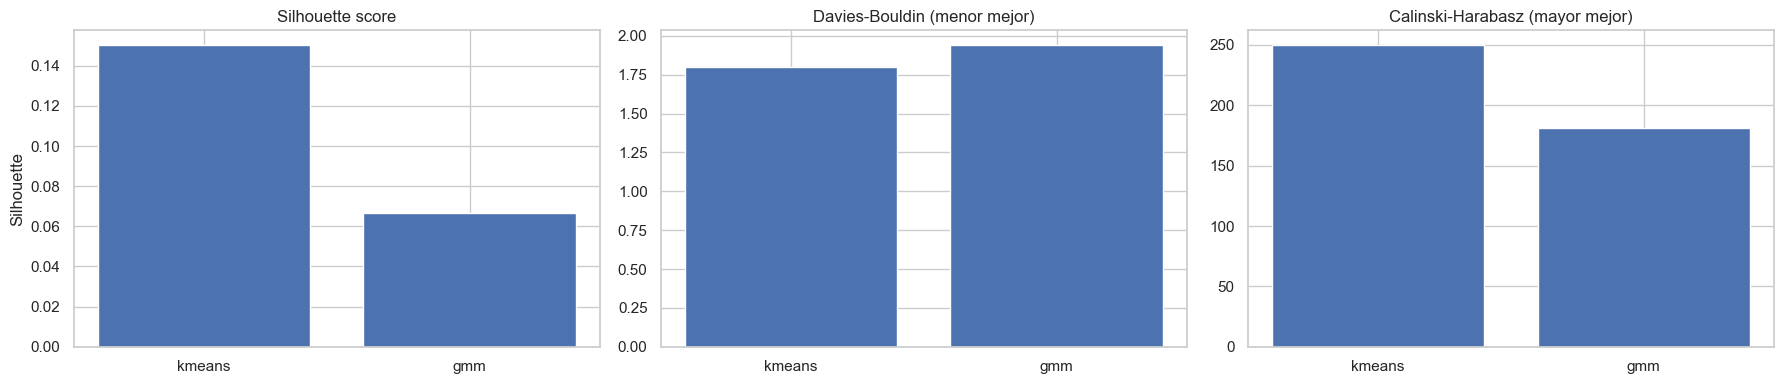

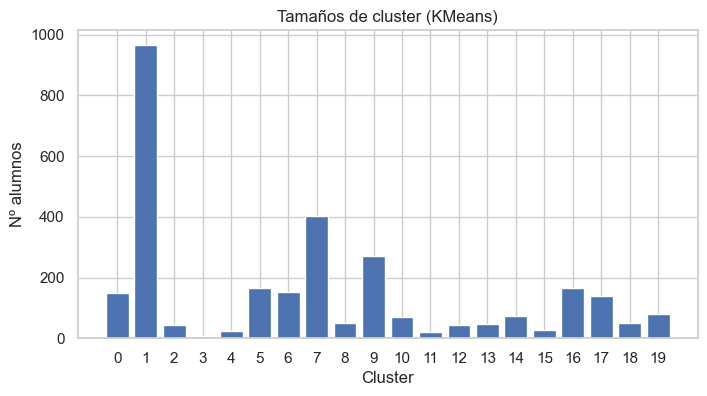


Top 10 afinidades por cluster (KMeans):

Cluster 0:
                                        asignatura   A_comp    A_pop   A_nota
TécnicasComputacionalesparalaIngenieríadelSoftware 0.870972 0.960000 0.781944
                        ModeladoyDiseñodelSoftware 0.854820 0.986667 0.722973
                 SeguridadenServiciosyAplicaciones 0.851310 0.933333 0.769286
                      TecnologíasdeAplicacionesWeb 0.848225 0.926667 0.769784
Softwareparasistemasempotradosydispositivosmóviles 0.841667 0.933333 0.750000
        MétodosformalesparalaIngenieríadelSoftware 0.839320 0.980000 0.698639
                             ProyectosyLegislación 0.837352 0.973333 0.701370
                                     IngenieríaWeb 0.835952 0.933333 0.738571
                        GestióndeProyectosSoftware 0.830238 0.933333 0.727143
                  MantenimientoyPruebasdelSoftware 0.829796 0.980000 0.679592

Cluster 1:
                                   asignatura   A_comp    A_pop   A_nota
    

In [70]:
# Celda: Evaluación comparativa (KMeans, GMM, HDBSCAN) usando crear_df(conn)
# Requisitos: pandas, numpy, scikit-learn, matplotlib, (opcional) hdbscan
# Si usas HDBSCAN: pip install hdbscan

import math
import warnings
from typing import Optional, Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Intento importar hdbscan (opcional)
try:
    import hdbscan  # type: ignore
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False
    warnings.warn("hdbscan no está instalado — HDBSCAN se omitirá. Instalar con `pip install hdbscan` si lo deseas.")

# ---------- UTIL: carga y limpieza ----------
def cargar_y_limpiar_desde_crear_df(conn) -> pd.DataFrame:
    """
    Usa la función crear_df(conn) que ya tienes definida en tu proyecto y
    devuelve un DataFrame limpio listo para pivotar:
    columnas esperadas: CODIGOALUM, NOMBREASIGNATURA, NUM_CALIFICACIÓN
    """
    # Llamamos a tu función crear_df (asegúrate de que está en el scope)
    df = crear_df(conn).copy()
    # Renombrar columnas por seguridad (si acaso)
    df.columns = [c.strip() for c in df.columns]

    # Normalizar nombre de asignatura (mantener original en otra columna si quieres)
    if "NOMBREASIGNATURA" not in df.columns:
        raise RuntimeError("crear_df(conn) debe devolver columna 'NOMBREASIGNATURA'")

    df["NOMBREASIGNATURA_ORIG"] = df["NOMBREASIGNATURA"].astype(str)
    df["NOMBREASIGNATURA"] = df["NOMBREASIGNATURA_ORIG"].str.replace(" ", "", regex=False).str.strip()

    # Normalizar NUM_CALIFICACIÓN: coma -> punto, a float
    df["NUM_CALIFICACIÓN"] = (
        df["NUM_CALIFICACIÓN"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["nan", "None", "NoneType", ""], np.nan)
    )
    df["NUM_CALIFICACIÓN"] = pd.to_numeric(df["NUM_CALIFICACIÓN"], errors="coerce")

    # Eliminar filas sin asignatura o sin alumno
    df = df[df["CODIGOALUM"].notnull() & df["NOMBREASIGNATURA"].notnull()]

    # Opcional: cast CODIGOALUM a string
    df["CODIGOALUM"] = df["CODIGOALUM"].astype(str)

    # Informar
    print(f"[INFO] filas totales después de limpieza: {len(df)}")
    print(f"[INFO] alumnos únicos: {df['CODIGOALUM'].nunique()} - asignaturas únicas: {df['NOMBREASIGNATURA'].nunique()}")
    return df

# ---------- UTIL: matriz alumno x asignatura ----------
def construir_matriz(df: pd.DataFrame) -> Tuple[pd.DataFrame, StandardScaler]:
    """
    Devuelve:
      - matriz (DataFrame) con index=CODIGOALUM, columns=NOMBREASIGNATURA, valores NUM_CALIFICACIÓN (NaN->0)
      - scaler (StandardScaler) ajustado a la matriz (pero devolvemos la matriz sin escalar también)
    """
    pivot = df.pivot_table(index="CODIGOALUM", columns="NOMBREASIGNATURA", values="NUM_CALIFICACIÓN")
    matriz = pivot.fillna(0.0)  # ausencia = 0 (no matriculado/no nota)
    scaler = StandardScaler()
    scaler.fit(matriz)  # Ajustar scaler (no transformamos todavía, se hace en cada modelo)
    return matriz, scaler

# ---------- MÉTRICAS ----------
def metrics_clustering(labels: np.ndarray, X_scaled: np.ndarray) -> Dict[str, Optional[float]]:
    """Calcula Silhouette, Davies-Bouldin y Calinski-Harabasz si aplican."""
    out = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_samples = X_scaled.shape[0]

    if n_clusters >= 2 and n_clusters < n_samples:
        try:
            out["silhouette"] = float(silhouette_score(X_scaled, labels))
        except Exception as e:
            out["silhouette"] = None
            warnings.warn(f"silhouette failed: {e}")
    if len(unique_labels) >= 2:
        try:
            out["davies_bouldin"] = float(davies_bouldin_score(X_scaled, labels))
        except Exception as e:
            out["davies_bouldin"] = None
            warnings.warn(f"davies_bouldin failed: {e}")
        try:
            out["calinski_harabasz"] = float(calinski_harabasz_score(X_scaled, labels))
        except Exception as e:
            out["calinski_harabasz"] = None
            warnings.warn(f"calinski_harabasz failed: {e}")
    return out

# ---------- AFINIDADES (resumen por cluster) ----------
def compute_cluster_affinities(df: pd.DataFrame, labels_series: pd.Series) -> pd.DataFrame:
    """
    Devuelve DataFrame con métricas por (cluster, asignatura):
      - alumnos_cluster: nº alumnos del cluster que aparecen en la asignatura
      - mean_nota: media de notas en esa asignatura para ese cluster
      - A_pop: fracción de alumnos del cluster que eligieron la asignatura
      - A_nota: mean_nota / 10 (0..1)
      - A_comp: combinación simple (por defecto 0.5*nota + 0.5*pop)
    """
    df2 = df.copy()
    df2["cluster"] = df2["CODIGOALUM"].map(labels_series)
    total_por_cluster = df2.groupby("cluster")["CODIGOALUM"].nunique().rename("total_cluster")
    grouped = df2.groupby(["cluster", "NOMBREASIGNATURA"])
    rows = []
    for (cluster, asign), g in grouped:
        alumnos_cluster = g["CODIGOALUM"].nunique()
        notas = g["NUM_CALIFICACIÓN"].dropna().astype(float)
        mean_nota = notas.mean() if not notas.empty else np.nan
        rows.append({
            "cluster": cluster,
            "asignatura": asign,
            "alumnos_cluster": alumnos_cluster,
            "mean_nota": mean_nota
        })
    df_aff = pd.DataFrame(rows)
    df_aff["total_cluster"] = df_aff["cluster"].map(total_por_cluster)
    df_aff["A_pop"] = df_aff["alumnos_cluster"] / df_aff["total_cluster"].replace(0, np.nan)
    df_aff["A_nota"] = df_aff["mean_nota"] / 10.0
    alpha, beta = 0.5, 0.5
    df_aff["A_comp"] = alpha * df_aff["A_nota"].fillna(0) + beta * df_aff["A_pop"].fillna(0)
    df_aff = df_aff.sort_values(["cluster", "A_comp"], ascending=[True, False])
    return df_aff

# ---------- RECALL@K sencillo (ocultar 1 asignatura por alumno) ----------
def recall_at_k(df: pd.DataFrame, labels_series: pd.Series, cluster_aff: pd.DataFrame, topk: int = 5) -> float:
    """
    Implementación de prueba: para cada alumno ocultamos aleatoriamente una asignatura y comprobamos si aparece en topk.
    No es exhaustivo, sirve para comparar algoritmos.
    """
    rng = np.random.default_rng(42)
    alumnos = df["CODIGOALUM"].unique()
    hits = 0
    trials = 0

    for alumno in alumnos:
        asignaturas = df[df["CODIGOALUM"] == alumno]["NOMBREASIGNATURA"].unique()
        if len(asignaturas) < 1:
            continue
        ocultada = rng.choice(asignaturas)
        # recomender por cluster (etiqueta dura)
        cluster = labels_series.get(alumno, None)
        if cluster is None:
            continue
        cand_df = cluster_aff[cluster_aff["cluster"] == cluster]
        recomendaciones = list(cand_df[~cand_df["asignatura"].isin(asignaturas)][["asignatura", "A_comp"]].head(topk)["asignatura"])
        # Si la ocultada aparece en recomendaciones -> acierto
        if ocultada in recomendaciones:
            hits += 1
        trials += 1

    return (hits / trials) if trials > 0 else 0.0

# ---------- PIPELINE principal para notebook ----------
def run_compare(conn,
                n_clusters: int = 12,
                topk: int = 5,
                run_kmeans: bool = True,
                run_gmm: bool = True,
                run_hdbscan: bool = True):
    """
    Ejecuta todo: carga df con crear_df(conn), construye matriz, entrena modelos y muestra prints + gráficas.
    Devuelve un dict con resultados.
    """
    df = cargar_y_limpiar_desde_crear_df(conn)
    matriz, scaler = construir_matriz(df)
    X = scaler.transform(matriz)  # numpy array escalada
    index = matriz.index

    results = {}

    # --- KMEANS ---
    if run_kmeans:
        print("\n[RUN] KMeans (k=%d)" % n_clusters)
        km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        km_labels = km.fit_predict(X)
        km_series = pd.Series(km_labels, index=index, name="cluster")
        metrics_km = metrics_clustering(km_labels, X)
        aff_km = compute_cluster_affinities(df, km_series)
        recall_km = recall_at_k(df, km_series, aff_km, topk=topk)
        results["kmeans"] = {"model": km, "labels": km_series, "metrics": metrics_km, "aff": aff_km, "recall@k": recall_km}
        print("Metrics KMeans:", metrics_km)
        print(f"Recall@{topk} KMeans: {recall_km:.3f}")
        # Imprimir tamaño de clusters
        print("Tamaños de cluster (KMeans):")
        print(km_series.value_counts().sort_index())

    # --- GMM ---
    if run_gmm:
        print("\n[RUN] GaussianMixture (k=%d)" % n_clusters)
        gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        gmm.fit(X)
        gmm_labels = gmm.predict(X)
        gmm_series = pd.Series(gmm_labels, index=index, name="cluster")
        metrics_gmm = metrics_clustering(gmm_labels, X)
        aff_gmm = compute_cluster_affinities(df, gmm_series)
        recall_gmm = recall_at_k(df, gmm_series, aff_gmm, topk=topk)
        results["gmm"] = {"model": gmm, "labels": gmm_series, "metrics": metrics_gmm, "aff": aff_gmm, "recall@k": recall_gmm}
        print("Metrics GMM:", metrics_gmm)
        print(f"Recall@{topk} GMM: {recall_gmm:.3f}")
        print("Tamaños de cluster (GMM):")
        print(gmm_series.value_counts().sort_index())

    # --- HDBSCAN (opcional) ---
    if run_hdbscan and HDBSCAN_AVAILABLE:
        print("\n[RUN] HDBSCAN (min_cluster_size ~ 1% de alumnos)")
        min_size = max(5, int(len(matriz) * 0.01))
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_size)
        hdb_labels = clusterer.fit_predict(X)
        hdb_series = pd.Series(hdb_labels, index=index, name="cluster")
        metrics_hdb = metrics_clustering(hdb_labels, X)
        aff_hdb = compute_cluster_affinities(df, hdb_series)
        recall_hdb = recall_at_k(df, hdb_series, aff_hdb, topk=topk)
        results["hdbscan"] = {"model": clusterer, "labels": hdb_series, "metrics": metrics_hdb, "aff": aff_hdb, "recall@k": recall_hdb}
        print("Metrics HDBSCAN:", metrics_hdb)
        print(f"Recall@{topk} HDBSCAN: {recall_hdb:.3f}")
        print("Tamaños de cluster (HDBSCAN):")
        print(hdb_series.value_counts().sort_index())
    elif run_hdbscan:
        print("[WARN] HDBSCAN no disponible — instala 'hdbscan' si quieres probarlo.")

    # --- GRAFICAS comparativas ---
    # 1) Comparativa de Silhouette / Davies / Calinski por algoritmo
    algos = []
    silhouette_vals, db_vals, ch_vals = [], [], []
    for algo in ["kmeans", "gmm", "hdbscan"]:
        r = results.get(algo)
        if r:
            algos.append(algo)
            silhouette_vals.append(r["metrics"]["silhouette"])
            db_vals.append(r["metrics"]["davies_bouldin"])
            ch_vals.append(r["metrics"]["calinski_harabasz"])

    # plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].bar(algos, [v if v is not None else 0 for v in silhouette_vals])
    axes[0].set_title("Silhouette score")
    axes[0].set_ylabel("Silhouette")

    axes[1].bar(algos, [v if v is not None else 0 for v in db_vals])
    axes[1].set_title("Davies-Bouldin (menor mejor)")

    axes[2].bar(algos, [v if v is not None else 0 for v in ch_vals])
    axes[2].set_title("Calinski-Harabasz (mayor mejor)")

    plt.tight_layout()
    plt.show()

    # 2) Histograma tamaños de cluster para KMeans (si existe)
    if "kmeans" in results:
        sizes = results["kmeans"]["labels"].value_counts().sort_index()
        plt.figure(figsize=(8,4))
        plt.bar(sizes.index.astype(str), sizes.values)
        plt.title("Tamaños de cluster (KMeans)")
        plt.xlabel("Cluster")
        plt.ylabel("Nº alumnos")
        plt.show()

    # 3) Mostrar top 10 afinidades por cluster (KMeans)
    if "kmeans" in results:
        print("\nTop 10 afinidades por cluster (KMeans):")
        top_aff = results["kmeans"]["aff"].groupby("cluster").head(10)
        for cluster in sorted(top_aff["cluster"].unique()):
            subset = top_aff[top_aff["cluster"] == cluster][["asignatura","A_comp","A_pop","A_nota"]]
            print(f"\nCluster {cluster}:")
            print(subset.to_string(index=False))

    return results

# ---------- Ejecutar (ejemplo) ----------
# Llama a run_compare(conn) en tu notebook (ajusta n_clusters/topk así lo necesites).
# Ejemplo:
results = run_compare(conn, n_clusters=20, topk=5, run_kmeans=True, run_gmm=True, run_hdbscan=False)



[INFO] filas: 54178, alumnos: 2953, asignaturas únicas: 165

=== RESUMEN METRICAS INTERNAS (silhouette) por k ===
k= 6 | base: 0.30945458423089045 | tit_feature: None
k= 8 | base: 0.2870693017849553 | tit_feature: None
k=10 | base: 0.1984089939967177 | tit_feature: None
k=12 | base: 0.13894160703437472 | tit_feature: None


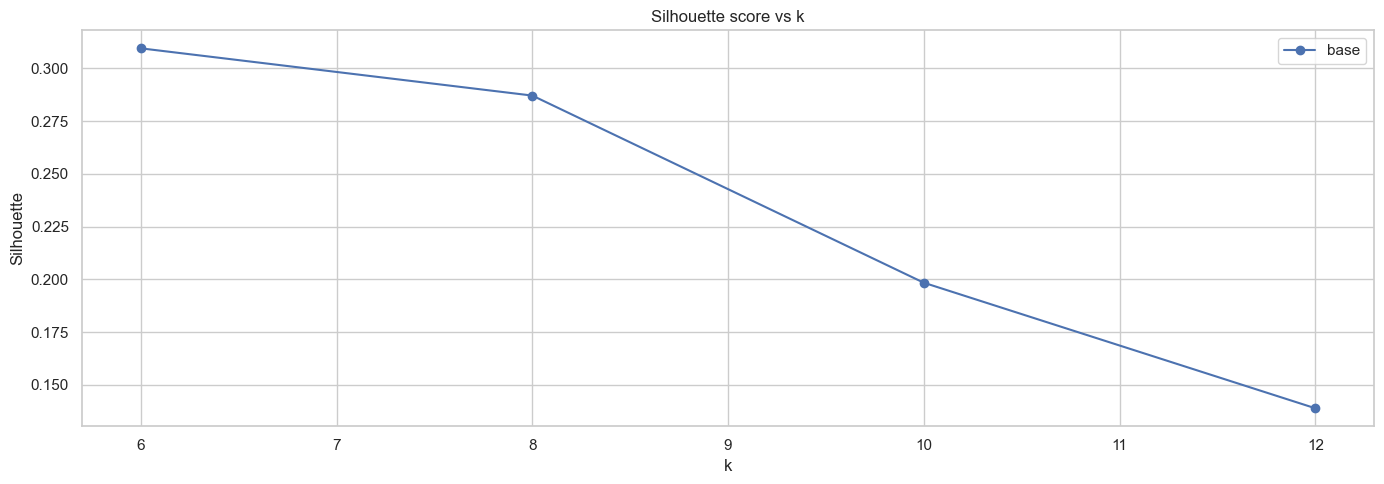


Tamaños cluster (base) para k=12:
0      143
1       62
2      483
3      156
4      359
5       72
6       49
7      313
8       30
9     1029
10     126
11     131
Name: count, dtype: int64


In [67]:
# Script para notebook: comparar KMeans (titulación como etiqueta vs titulacion como feature)
# Requisitos: pandas, numpy, scikit-learn, matplotlib, seaborn (opcional)
# Ejemplo de uso:
# results = comparar_kmeans_titulacion(conn, k_list=[6,8,10,12], topk=5)

import warnings
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

sns.set(style="whitegrid")
warnings.filterwarnings("ignore")


# ----------------- UTIL: cargar y limpiar -----------------
def cargar_y_preparar(conn) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Llama a crear_df(conn) y normaliza columnas.
    Devuelve:
      - df_long: DataFrame largo con columnas CODIGOALUM, NOMBREASIGNATURA, NUM_CALIFICACIÓN
      - df_alumnos: DataFrame con CODIGOALUM y TITULACION (primeros 4 chars)
    """
    df_long = crear_df(conn).copy()  # tu función existente
    df_long.columns = [c.strip() for c in df_long.columns]

    # Normalizar nombre de asignatura (sin espacios para consistencia)
    df_long["NOMBREASIGNATURA"] = df_long["NOMBREASIGNATURA"].astype(str).str.replace(" ", "", regex=False).str.strip()

    # Normalizar NUM_CALIFICACIÓN: coma -> punto y cast a float (NaN si no convertible)
    df_long["NUM_CALIFICACIÓN"] = (
        df_long["NUM_CALIFICACIÓN"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["nan", "None", "NoneType", ""], np.nan)
    )
    df_long["NUM_CALIFICACIÓN"] = pd.to_numeric(df_long["NUM_CALIFICACIÓN"], errors="coerce")

    # Filtrar registros sin alumno o asignatura
    df_long = df_long[df_long["CODIGOALUM"].notnull() & df_long["NOMBREASIGNATURA"].notnull()]

    # Crear tabla de alumnos con titulacion (primeros 4 caracteres)
    df_alumnos = df_long[["CODIGOALUM"]].drop_duplicates().reset_index(drop=True)
    df_alumnos["TITULACION"] = df_alumnos["CODIGOALUM"].astype(str).str[:4]

    print(f"[INFO] filas: {len(df_long)}, alumnos: {df_alumnos.shape[0]}, asignaturas únicas: {df_long['NOMBREASIGNATURA'].nunique()}")
    return df_long, df_alumnos


# ----------------- UTIL: pivot matriz -----------------
def crear_matriz(df_long: pd.DataFrame) -> pd.DataFrame:
    """
    Retorna matriz alumno x asignatura (index CODIGOALUM, columnas NOMBREASIGNATURA)
    valores NUM_CALIFICACIÓN, NaN -> 0
    """
    pivot = df_long.pivot_table(index="CODIGOALUM", columns="NOMBREASIGNATURA", values="NUM_CALIFICACIÓN")
    matriz = pivot.fillna(0.0)
    return matriz


# ----------------- METRICAS (externas) -----------------
def purity_score(labels_true: np.ndarray, labels_pred: np.ndarray) -> float:
    """
    Purity = (1/N) * sum_c max_j |omega_c ∩ y_j|
    """
    contingency = pd.crosstab(labels_pred, labels_true)
    return contingency.max(axis=1).sum() / contingency.values.sum()


# ----------------- EVALUACIÓN KMEANS -----------------
def evaluar_kmeans(X: np.ndarray, labels_true: Optional[np.ndarray], k: int, random_state: int = 42) -> Dict:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X)

    # métricas internas
    metrics_internas = {}
    try:
        metrics_internas["silhouette"] = float(silhouette_score(X, labels)) if len(set(labels)) > 1 else None
    except Exception:
        metrics_internas["silhouette"] = None
    try:
        metrics_internas["davies_bouldin"] = float(davies_bouldin_score(X, labels)) if len(set(labels)) > 1 else None
    except Exception:
        metrics_internas["davies_bouldin"] = None
    try:
        metrics_internas["calinski_harabasz"] = float(calinski_harabasz_score(X, labels)) if len(set(labels)) > 1 else None
    except Exception:
        metrics_internas["calinski_harabasz"] = None

    # métricas externas si labels_true dadas
    metrics_externas = None
    if labels_true is not None:
        metrics_externas = {
            "ARI": adjusted_rand_score(labels_true, labels),
            "AMI": adjusted_mutual_info_score(labels_true, labels),
            "homogeneity": homogeneity_score(labels_true, labels),
            "completeness": completeness_score(labels_true, labels),
            "v_measure": v_measure_score(labels_true, labels),
            "purity": purity_score(labels_true, labels)
        }

    # tamaños de cluster
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()

    return {
        "model": km,
        "labels": labels,
        "metrics_internas": metrics_internas,
        "metrics_externas": metrics_externas,
        "sizes": sizes
    }


# ----------------- MAIN: comparar escenarios -----------------
def comparar_kmeans_titulacion(conn,
                               k_list: List[int] = [6, 8, 10, 12],
                               usar_titulacion_como_feature: bool = False,
                               encoder_onehot: bool = True,
                               random_state: int = 42) -> Dict:
    """
    Ejecuta KMeans para cada k en k_list y devuelve resultados:
      - escenario 'solo_features' (matriz alumno×asignatura)
      - escenario 'titulacion_feature' (si usar_titulacion_como_feature=True)
    Si usar_titulacion_como_feature es False -> se sigue probando el *label* (comparación externa)
    """
    df_long, df_alumnos = cargar_y_preparar(conn)
    matriz = crear_matriz(df_long)  # DataFrame index CODIGOALUM

    # escalar features (importante)
    scaler = StandardScaler()
    X_base = scaler.fit_transform(matriz)

    # obtener labels verdaderos (titulacion) alineados con matriz.index
    titulaciones_map = df_alumnos.set_index("CODIGOALUM")["TITULACION"].to_dict()
    labels_true = np.array([titulaciones_map.get(idx, "UNK") for idx in matriz.index])

    # si queremos usar titulación como feature, codificar y añadir a X
    X_with_tit = None
    if usar_titulacion_como_feature:
        # One-hot encode según df_alumnos (asegurar orden igual a matriz.index)
        tit_series = pd.Series([titulaciones_map.get(idx, "UNK") for idx in matriz.index], index=matriz.index, name="TITULACION")
        if encoder_onehot:
            ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            ohe_mat = ohe.fit_transform(tit_series.values.reshape(-1, 1))
            # concatenar
            X_with_tit = np.hstack([X_base, ohe_mat])
        else:
            # label encoding simple (no recomendado, pero disponible)
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            le_vals = le.fit_transform(tit_series.values).reshape(-1, 1)
            X_with_tit = np.hstack([X_base, le_vals.astype(float)])
        # volver a escalar después de concatenar (opcional pero recomendable)
        X_with_tit = StandardScaler().fit_transform(X_with_tit)

    results = {"solo_features": {}, "titulacion_feature": {}}

    # Ejecutar para cada k
    for k in k_list:
        # escenario base
        res_base = evaluar_kmeans(X_base, labels_true, k, random_state=random_state)
        results["solo_features"][k] = res_base

        # escenario con titulacion feature (si pedido)
        if usar_titulacion_como_feature:
            res_tit = evaluar_kmeans(X_with_tit, labels_true, k, random_state=random_state)
            results["titulacion_feature"][k] = res_tit

    # PRINT/plot resumido
    print("\n=== RESUMEN METRICAS INTERNAS (silhouette) por k ===")
    for k in k_list:
        s_base = results["solo_features"][k]["metrics_internas"]["silhouette"]
        s_tit = None
        if usar_titulacion_como_feature:
            s_tit = results["titulacion_feature"][k]["metrics_internas"]["silhouette"]
        print(f"k={k:2d} | base: {s_base} | tit_feature: {s_tit}")

    # Graficas comparativas (silhouette, ARI si labels_true present)
    fig, axes = plt.subplots(1, 2 if usar_titulacion_como_feature else 1, figsize=(14, 5))
    # Silhouette
    ks = []
    vals_base = []
    vals_tit = []
    for k in k_list:
        ks.append(k)
        vals_base.append(results["solo_features"][k]["metrics_internas"]["silhouette"] or 0)
        if usar_titulacion_como_feature:
            vals_tit.append(results["titulacion_feature"][k]["metrics_internas"]["silhouette"] or 0)

    ax0 = axes[0] if usar_titulacion_como_feature else axes
    ax0.plot(ks, vals_base, marker="o", label="base")
    if usar_titulacion_como_feature:
        ax0.plot(ks, vals_tit, marker="o", label="titulacion_feature")
    ax0.set_title("Silhouette score vs k")
    ax0.set_xlabel("k")
    ax0.set_ylabel("Silhouette")
    ax0.legend()

    # ARI (externa) - útil si labels_true tiene sentido
    if usar_titulacion_como_feature:
        ari_base = [results["solo_features"][k]["metrics_externas"]["ARI"] for k in k_list]
        ari_tit = [results["titulacion_feature"][k]["metrics_externas"]["ARI"] for k in k_list]
        ax1 = axes[1]
        ax1.plot(ks, ari_base, marker="o", label="ARI base")
        ax1.plot(ks, ari_tit, marker="o", label="ARI tit_feature")
        ax1.set_title("ARI vs k")
        ax1.set_xlabel("k")
        ax1.set_ylabel("ARI")
        ax1.legend()

    plt.tight_layout()
    plt.show()

    # Mostrar tablas con tamaños y métricas para k seleccionado (ej: k_list[-1])
    sel_k = k_list[-1]
    print(f"\nTamaños cluster (base) para k={sel_k}:")
    print(pd.Series(results["solo_features"][sel_k]["labels"]).value_counts().sort_index())
    if usar_titulacion_como_feature:
        print(f"\nTamaños cluster (tit_feature) para k={sel_k}:")
        print(pd.Series(results["titulacion_feature"][sel_k]["labels"]).value_counts().sort_index())

    return results


# ----------------- EJECUTAR ejemplo -----------------
# Llama a esta función en el notebook con tu conexión 'conn'
results = comparar_kmeans_titulacion(conn, k_list=[6,8,10,12], usar_titulacion_como_feature=False)


In [36]:
# Función para construir la matriz de alumnos
def construir_matriz(df):
    matriz = df.pivot_table(index='CODIGOALUM', columns='NOMBREASIGNATURA', values='NUM_CALIFICACIÓN')
    matriz = matriz.fillna(0)
    return matriz

# Método del codo
def metodo_del_codo(matriz, max_k=10):
    scaler = StandardScaler()
    matriz_escalada = scaler.fit_transform(matriz)
    
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(matriz_escalada)
        inercia.append(kmeans.inertia_)
    
    # Graficar el codo
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia (WCSS)')
    plt.title('Método del Codo')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()
    #plt.savefig()

    return inercia  # Por si quieres usarla luego


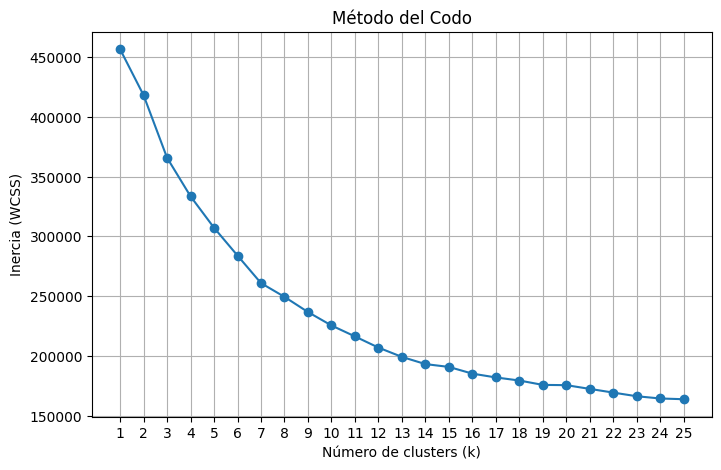

[456412.00000000023,
 417969.74960468395,
 365682.0004226274,
 333455.3114686267,
 307172.0076469106,
 283933.75313446176,
 260900.22994544875,
 249405.81228483203,
 236722.7811413316,
 225495.79693129176,
 216346.9395128646,
 206999.713495923,
 199219.93179123077,
 193213.42963573453,
 190847.11799482704,
 185235.51146762536,
 182050.12790780925,
 179483.96130574186,
 175815.05600397827,
 175608.1319643149,
 172482.91834955476,
 169376.43650320487,
 166332.131139719,
 164462.1288411832,
 163844.4022112258]

In [37]:
matriz = construir_matriz(df)
metodo_del_codo(matriz, max_k=25)

Añadir registro al DataFrame

In [33]:
def agregar_calificacion():
    nueva_fila = {
        "CODIGOALUM": "nuevo-alumno",
        "NOMBREASIGNATURA": "VisiónporComputador",
        "NUM_CALIFICACIÓN": "6"
    }
    
    df = crear_df(conn)

    # Agregar y quedarnos solo con la calificación más alta por alumno/asignatura
    df = pd.concat([df, pd.DataFrame([nueva_fila])], ignore_index=True)

    # Simula el ROW_NUMBER() en pandas
    df = (
        df.sort_values("NUM_CALIFICACIÓN", ascending=False)
          .drop_duplicates(subset=["CODIGOALUM", "NOMBREASIGNATURA"], keep="first")
          .reset_index(drop=True)
    )
    
    print(df)

    return {"message": "Calificación agregada exitosamente"}

agregar_calificacion()


C:\Users\6003480\AppData\Local\Temp\ipykernel_29764\3052612212.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


                             CODIGOALUM                     NOMBREASIGNATURA  \
0      C31F8DE915B39B8F0E53B77EB4E66E51             AprendizajeComputacional   
1      7B1657783A655FFD75B56CBE0A6223FA                       MineríadeDatos   
2      87EEC8DD8A46988BCF216B19416D911B          FundamentosdelaProgramación   
3      6EE17626B40DCBAC5B44FC608C2E7BE5                    PrácticasExternas   
4      6EE17626B40DCBAC5B44FC608C2E7BE5           ModeladoyDiseñodelSoftware   
...                                 ...                                  ...   
54174  EF01B877E3BC8F8F0D8410ACA3D1F967             CálculoparalaComputación   
54175  4BA607939ABDA8780172230DEA2FD2E8                   SistemasOperativos   
54176  80A6F8759A92D249CB78044429B90948        ProcesamientodeImágenesyVideo   
54177  4BA607939ABDA8780172230DEA2FD2E8  TeoríadeAutómatasyLenguajesFormales   
54178  6090252EE534F0BB4FB0B29A14CF620F                   MatemáticaDiscreta   

      NUM_CALIFICACIÓN  
0             

{'message': 'Calificación agregada exitosamente'}

Leer PDF y extraer los datos

In [34]:
PDF_PATH_TORRE = "C:/Users/jechi/Downloads/ListadoConsultaExpedienteAcademico.pdf"
PDF_PATH_PORTATIL = "C:/Users/6003480/Downloads/ListadoConsultaExpedienteAcademico.pdf"
KEY_PHRASE = "DATOS RELATIVOS A LAS ACTIVIDADES FORMATIVAS REALIZADAS EN EL CENTRO:"

def extract_tables_after_phrase(pdf_path):
    tables = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            page.extract_text()
            page_tables = page.extract_tables()
            for table in page_tables:
                if table:  # Evita tablas vacías
                    tables.append(table)

    return tables

tablas = extract_tables_after_phrase(PDF_PATH_PORTATIL)

for idx, table in enumerate(tablas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table[:5]:  # Solo imprimir las primeras 3 filas
        print(row)


--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 'Créditos', 'Curso Acad.', 'Convocatoria', 'Calif.Num.', 'Calif.Literal'

Para los valores None de nombre de asignatura, les pongo el nombre que les corresponde

In [35]:
def rellenar_asignaturas(tabla, indice_columna=0, ultima_asignatura=None):
    "Reemplaza valores None o vacíos por el último valor no vacío encontrado en una columna."
    asignatura = ultima_asignatura
    nueva_tabla = []

    for fila in tabla:
        fila_copia = fila.copy()
        valor = fila_copia[indice_columna]

        if valor and valor.strip() and valor != "DATOS RELATIVOS A LAS ACTIVIDADES FORMATIVAS REALIZADAS EN EL CENTRO:":
            asignatura = valor.strip()
            nueva_tabla.append(fila_copia)
        else:
            # El valor es None o vacío → usar última asignatura
            
            fila_copia[indice_columna] = asignatura
            # Eliminar la fila anterior (misma asignatura)
            if nueva_tabla and nueva_tabla[-1][indice_columna] == asignatura:
                nueva_tabla.pop()
            nueva_tabla.append(fila_copia)

    return nueva_tabla, asignatura

tablas = extract_tables_after_phrase(PDF_PATH_PORTATIL)

tablas_procesadas = []
ultima_asignatura = None

for tabla in tablas:
    tabla_procesada, ultima_asignatura = rellenar_asignaturas(tabla, indice_columna=0, ultima_asignatura=ultima_asignatura)
    tablas_procesadas.append(tabla_procesada)

for idx, table in enumerate(tablas_procesadas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table:
        print(row)





--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 'Créditos', 'Curso Acad.', 'Convocatoria', 'Calif.Num.', 'Calif.Literal'

Quito las filas con valores innecesarios, y aplico la función rellenar_asignaturas sobre las tablas tras limpiarlas

In [36]:
def limpiar_tabla(tabla, frase_objetivo, ultima_asignatura=None):
    tabla_limpia = []

    # Paso 1: eliminar filas basura
    for fila in tabla:
        if fila[0] == frase_objetivo and all(c in [None, '', ' '] for c in fila[1:]):
            continue
        tabla_limpia.append(fila)

    if not tabla_limpia:
        return [], ultima_asignatura

    # Paso 2: eliminar primera columna si todas tienen None
    if all(fila[0] is None for fila in tabla_limpia):
        tabla_limpia = [fila[1:] for fila in tabla_limpia]

    # Paso 3: rellenar asignaturas y devolver la última
    tabla_rellena, ultima_asignatura = rellenar_asignaturas(tabla_limpia, indice_columna=0, ultima_asignatura=ultima_asignatura)

    return tabla_rellena, ultima_asignatura


tablas = extract_tables_after_phrase(PDF_PATH_PORTATIL)
tablas_procesadas = []
ultima_asignatura = None

for tabla in tablas:
    if not tabla:
        continue
    tabla_limpia, ultima_asignatura = limpiar_tabla(tabla, KEY_PHRASE, ultima_asignatura)
    tablas_procesadas.append(tabla_limpia)


for idx, table in enumerate(tablas_procesadas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table:
        print(row)



--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 'Créditos', 'Curso Acad.', 'Convocatoria', 'Calif.Num.', 'Calif.Literal'

In [37]:
def limpiar_tablas_finales(tablas):
    tablas_limpias = []

    for tabla in tablas:
        # Saltar si la tabla tiene 3 columnas o menos
        if len(tabla[0]) <= 3:
            continue

        # Eliminar filas con encabezado 'Denominación asignatura'
        tabla_sin_encabezado = [fila for fila in tabla if fila[0] != 'Denominación asignatura']

        # Saltar tablas vacías tras limpieza
        if not tabla_sin_encabezado:
            continue

        tablas_limpias.append(tabla_sin_encabezado)

    # Eliminar la última tabla si queda alguna
    if tablas_limpias:
        tablas_limpias = tablas_limpias[:-1]

    return tablas_limpias

tablas_finales = limpiar_tablas_finales(tablas_procesadas)

# Ejemplo para imprimir
for idx, tabla in enumerate(tablas_finales, start=0):
    print(f"\n--- Tabla limpia {idx + 1} ---")
    for fila in tabla:
        print(fila)

codigoalum= '104101657'

cur = conn.cursor()
for tabla in tablas_finales:
    for fila in tabla:
        cur.execute("""
                INSERT INTO informes_alumno
                (
                CODIGOALUM, NOMBREASIGNATURA, CREDITOS, CURSO_ACADÉMICO,
                CONVOCATORIA, NUM_CALIFICACIÓN, CALIFICACIÓN
                ) VALUES (:1, :2, :3, :4, :5, :6, :7)
""", (codigoalum, fila[0], fila[1], fila[2], fila[3], fila[4], fila[5]))
        
conn.commit()




--- Tabla limpia 1 ---
['Modelado y Simulación de Sistemas', '6', '2022/23', 'MAY/2023', '7.50', 'Notable']

--- Tabla limpia 2 ---
['Desarrollo de Software Crítico', '6', '2024/25', 'ENE/2025', '5.50', 'Aprobado']

--- Tabla limpia 3 ---
['Gestión Inteligente de la Información', '6', '2024/25', 'JUN/2025', '5.00', 'Aprobado']

--- Tabla limpia 4 ---
['Procesadores de Lenguajes', '6', '2024/25', 'Eval.', '5.00', 'Aprobado']

--- Tabla limpia 5 ---
['Sistemas Inteligentes II', '6', '2022/23', 'MAY/2023', '6.00', 'Aprobado']

--- Tabla limpia 6 ---
['Organización Empresarial', '6', '2020/21', 'JUN/2021', '6.20', 'Aprobado']

--- Tabla limpia 7 ---
['Métodos Estadísticos para la Computación', '6', '2023/24', 'JUN/2024', '9.00', 'Sobresaliente']

--- Tabla limpia 8 ---
['Fundamentos Físicos de la Informática', '6', '2023/24', 'ENE/2024', '3.20', 'Suspenso']

--- Tabla limpia 9 ---
['Fundamentos Físicos de la Informática', '6', '2023/24', 'FEB/2024', '5.50', 'Aprobado']
['Fundamentos de El

In [38]:
def calcular_media_ponderada_completa(df: pd.DataFrame, tablas_pdf: list, codigo_alumno: str):
    total_creditos = 0

    for tabla in tablas_pdf:
        for fila in tabla:
            if len(fila) < 6:
                continue

            asignatura = fila[0]
            creditos = fila[1]
            curso = fila[2]
            nota_str = fila[4]
            calificacion_literal = fila[5]

            # Validar datos necesarios
            if not asignatura or not nota_str or not creditos or not curso or not calificacion_literal:
                continue

            # Validar calificación aprobada
            calif_normalizada = calificacion_literal.strip().upper()
            if calif_normalizada in ["SUSPENSO", "NO PRESENTADO"]:
                continue
            total_creditos = float(creditos) + total_creditos

    # Filtrar registros del DF
    df_filtrado = df[
        (df["CODIGOALUM"] == codigo_alumno) &
        (df["NUM_CALIFICACIÓN"].astype(float) >= 5)
    ]
        
    try:
        notas_df = df_filtrado["NUM_CALIFICACIÓN"].astype(float)
        media_df = notas_df.mean()
        aprobadas_df = len(df_filtrado)
        
    except Exception:
        media_df = None
        total_creditos = 0
        aprobadas_df = 0
        
    # Agregar datos del PDF

    ponderada = round((media_df) * (total_creditos / 240), 2)
    return (ponderada, aprobadas_df)

    
def calcular_probabilidad_entrada_df(conn, nombre_asignatura, df ,codigo_alumno, datos_pdf):
    # Obtener las notas de corte por año
    notas_corte = calcular_nota_corte(conn, nombre_asignatura)

    if not notas_corte:
        return 0.0  # No hay base para calcular probabilidad

    total = 0
    supera = 0

    media_alumno, aprobadas = calcular_media_ponderada_completa(df, datos_pdf , codigo_alumno)
    #media_alumno = 0.15
    for curso_acad, nota_corte in notas_corte.items():
        
        if media_alumno is not None:
            total += 1
            if media_alumno > nota_corte:
                supera += 1

    if total == 0:
        return 0.0  # El alumno no tiene historial válido

    probabilidad = (supera / total) * 100
    return round(probabilidad, 2)



In [39]:
num_expediente = '104101657'

def normalizar_asignatura(nombre: str) -> str:
    return nombre.replace(" ", "").strip()

def convertir_pdf_a_df(lista_tablas, codigo_alumno):
    datos_limpios = []

    for tabla in lista_tablas:
        for fila in tabla:
            asignatura = fila[0]
            nota_str = fila[4]

            if not asignatura or not nota_str:
                continue

            try:
                nota = float(nota_str.replace(',', '.'))
            except ValueError:
                continue  # Ignorar notas no numéricas

            datos_limpios.append({
                "CODIGOALUM": codigo_alumno,
                "NOMBREASIGNATURA": asignatura.replace(" ", "").strip(),
                "NUM_CALIFICACIÓN": nota
            })

    return pd.DataFrame(datos_limpios)

tablas = extract_tables_after_phrase(PDF_PATH_PORTATIL)
tablas_procesadas = [limpiar_tabla(tabla, KEY_PHRASE) for tabla in tablas if tabla]
datos_pdf = limpiar_tablas_finales(tablas_procesadas)

df_bd = crear_df(conn)
df_pdf = convertir_pdf_a_df(datos_pdf, num_expediente)

df_total = pd.concat([df_bd, df_pdf], ignore_index=True)

modelo, scaler, matriz, df_clusters = entrenar_clustering(df_total)
afinidad = predecir_afinidad_cluster(num_expediente, 'VisiónporComputador', modelo, scaler, matriz, df_clusters, df_total)
media = calcular_media_ponderada_completa(df_total, datos_pdf , num_expediente)
print(f"Media ponderada: {media[0]} con {media[1]} asignaturas aprobadas")
probabilidad_entrada = calcular_probabilidad_entrada_df(conn, 'VisiónporComputador', df_total ,'104101657', datos_pdf)
print(f"Probabilidad de entrada: {probabilidad_entrada}%")
print(f"Afinidad estimada: {afinidad}")


C:\Users\6003480\AppData\Local\Temp\ipykernel_29764\3052612212.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


IndexError: list index out of range

In [ ]:
def obtener_optativas_por_titulación(id: str):
    titulacion = int(id[:4])
    cur = conn.cursor()
    cur.execute("""
                SELECT nombre
                FROM v_optativas
                WHERE titulacion = :titulacion_alumno AND UPPER(ofertada) IN ('SI', 'SÍ')
                """, titulacion_alumno=titulacion)
    optativas = cur.fetchall()
    return optativas

print(obtener_optativas_por_titulación('104101657'))

[('Arquitecturas Virtuales',), ('Desarrollo de Software Crítico',), ('Electrónica Digital',), ('Herramientas de Diseño Electrónico',), ('Ingeniería de Protocolos',), ('Inteligencia Artificial para Juegos',), ('Redes Inalámbricas',), ('Teoría de Dominios y Modelos Denotacionales',), ('Teoría de la Información y la Codificación',), ('Visión por Computador',), ('Arquitecturas Cluster',), ('Arquitecturas Especializadas',), ('Calidad de Software',), ('Cognición y Comunicación en Ingeniería del Software',), ('Electrónica para Domótica',), ('Gestión Inteligente de la Información',), ('Laboratorio de Computación Científica',), ('Modelado y Simulación de Sistemas',), ('Prácticas Externas',), ('Procesamiento de Imágenes y Video',), ('Programación de Robots',), ('Programación de Videojuegos',), ('Sistemas de Información para la Industria',)]


Comprobar si los datos del alumno son válidos

In [ ]:
def obtener_verificacion_pdf(pdf_path) -> list[str]:
    lineas_extraidas = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            texto = page.extract_text()
            if texto:
                lineas = texto.split('\n')
                lineas_extraidas.extend(lineas[:5])
                break

    return lineas_extraidas[1], lineas_extraidas[4] if lineas_extraidas else None



resultados = obtener_verificacion_pdf(PDF_PATH_PORTATIL)
print(resultados)    

def verificar_pdf(dni:str , id: str):
    if not dni or not id:
        return 'No se han proporcionado DNI o ID válidos.'

    dni_pdf, id_pdf = obtener_verificacion_pdf(PDF_PATH_PORTATIL)
    dni_pdf = dni_pdf[14:]
    id_pdf = id_pdf[14:]
    
    if dni_pdf.strip() != dni.upper():
        return f'DNI no coincide: {dni_pdf.strip()} != {dni.upper()}'
    
    if id_pdf.strip() != id.upper():
        return f'ID no coincide: {id_pdf.strip()} != {id.upper()}'
    
    return 'Verificación exitosa'

verificar_pdf('0860b', '104101657')

('D.N.I. nº 77230860B', 'Expediente nº: 104101657')


'Verificación exitosa'

Borrado de la base de datos

In [ ]:
def borrar_alumno (id:str):
    cur = conn.cursor()
    cur.execute("""
        DELETE FROM informes_alumno
        WHERE CODIGOALUM = :codigo
    """, codigo=id)
    conn.commit()
    return {"message": f"Alumno con ID {id} borrado exitosamente."}

borrar_alumno('104101657')

{'message': 'Alumno con ID 104101657 borrado exitosamente.'}

In [ ]:
def extraer_tablas(pdf_path):
    tables = []
    lineas_extraidas = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            texto = page.extract_text()
            if texto:
                lineas = texto.split('\n')
                lineas_extraidas.extend(lineas[:5])
            page_tables = page.extract_tables()
            for table in page_tables:
                if table:  # Evita tablas vacías
                    tables.append(table)

    return tables, lineas_extraidas[1], lineas_extraidas[4]

tablas, dni_pdf, id_pdf = extraer_tablas(PDF_PATH_PORTATIL)
print(f"DNI extraído: {dni_pdf}")
print(f"ID extraído: {id_pdf}")
for idx, table in enumerate(tablas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table[:5]:  # Solo imprimir las primeras 5 filas
        print(row)

DNI extraído: D.N.I. nº 77230860B
ID extraído: Expediente nº: 104101657

--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 